<a href="https://colab.research.google.com/github/Mohameddacar/heart-disease-risk-score/blob/main/ai-ml/heart-disease-risk-score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Connect Google Drive to Colab
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# **1. Import pandas and load the data**



In [2]:
# Import pandas
import pandas as pd

In [2]:
# Check the versions used to train the model
import sys
import sklearn
import pandas
import joblib

print("Python version      :", sys.version)
print("Scikit-learn version:", sklearn.__version__)
print("Pandas version      :", pandas.__version__)
print("Joblib version      :", joblib.__version__)

Python version      : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Scikit-learn version: 1.6.1
Pandas version      : 2.2.3
Joblib version      : 1.5.3


In [3]:
# File location
file_path = "/content/drive/MyDrive/heart_disease/heart_disease.csv"

# Read the heart disease dataset
heart_df = pd.read_csv(file_path)
print("Dataset loaded successfully!")

Dataset loaded successfully!


# **2. Show the first five rows**

In [4]:
# Display the first 5 rows
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


In [5]:
# Number of rows and columns
heart_df.shape


(1024, 15)

In [6]:
# Display column names
heart_df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target_binary'],
      dtype='object')

# **3. Check dataset information**

In [7]:
# Data types and missing values
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1024 non-null   float64
 1   sex            1024 non-null   int64  
 2   cp             1024 non-null   int64  
 3   trestbps       1024 non-null   float64
 4   chol           1024 non-null   float64
 5   fbs            1024 non-null   int64  
 6   restecg        1024 non-null   int64  
 7   thalach        1024 non-null   float64
 8   exang          1024 non-null   int64  
 9   oldpeak        1024 non-null   float64
 10  slope          1024 non-null   int64  
 11  ca             1024 non-null   float64
 12  thal           1024 non-null   float64
 13  num            1024 non-null   int64  
 14  target_binary  1024 non-null   int64  
dtypes: float64(7), int64(8)
memory usage: 120.1 KB


# **4. Show statistical summary**

In [8]:
# Summary of numerical columns
heart_df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
count,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,54.532202,0.685547,3.149414,131.478621,246.965108,0.165039,1.001953,149.638107,0.345703,1.090142,1.619141,0.681641,4.701172,0.923828,0.458984
std,9.273400,0.464525,0.971812,17.506230,52.561237,0.371397,0.993624,23.480260,0.475829,1.072306,0.620176,0.947402,1.941107,1.070377,0.498558
min,18.000000,0.000000,1.000000,84.869643,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.193472,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.555581,0.000000,0.152062,1.000000,0.000000,3.000000,0.000000,0.000000
50%,55.000000,1.000000,3.000000,130.012111,244.996816,0.000000,1.000000,151.524700,0.000000,0.854977,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.196437,1.000000,4.000000,142.412148,280.232245,0.000000,2.000000,165.642437,1.000000,1.630471,2.000000,1.000000,7.000000,2.000000,1.000000
max,78.795030,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,227.196592,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


# **5. Check missing values**

In [9]:
# Count missing values in every column
heart_df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


# **6. Check duplicate rows**

In [10]:

# Count duplicated rows
heart_df.duplicated().sum()


np.int64(0)

# **7. Show the last five rows**

In [11]:
# Display the last 5 rows
heart_df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
1019,60.072205,1,3,115.422056,181.768595,0,0,128.155858,1,1.001941,2,1.0,7.0,2,1
1020,70.928404,1,2,166.727221,244.993631,1,0,108.481311,0,0.698337,2,1.0,7.0,2,1
1021,57.332875,1,2,105.075177,233.146324,0,2,140.342007,0,1.519138,1,0.0,7.0,2,1
1022,40.881554,0,4,125.068578,154.370678,1,2,123.756294,0,1.936684,2,1.0,7.0,2,1
1023,46.863367,1,3,121.909777,291.175476,1,2,146.652276,1,1.913951,2,2.0,3.0,2,1


# **Heart Disease Risk Classification**
# Step 8: Import the remaining libraries

In [12]:
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Split the dataset
from sklearn.model_selection import train_test_split

# Data preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Connect preprocessing and models
from sklearn.pipeline import Pipeline

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save and load the final model
import joblib

# Step 9: Create a copy

In [13]:
# Create a copy of the original dataset
new_df = heart_df.copy()

new_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


# Step 10: Clean the column names

In [14]:
# Remove unnecessary spaces from column names
new_df.columns = new_df.columns.str.strip()

print(new_df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target_binary']


# **Step 11: Confirm the target definition**

The supplied target is target_binary.

0 = Lower heart-disease risk class
1 = Higher heart-disease risk class

This is an educational risk classification, not a medical diagnosis.

In [15]:
# Display the target classes
print(new_df["target_binary"].value_counts())

# Compare num with the supplied binary target
pd.crosstab(
    new_df["num"],
    new_df["target_binary"],
    rownames=["Original num"],
    colnames=["Target class"]
)

target_binary
0    554
1    470
Name: count, dtype: int64


Target class,0,1
Original num,,
0,554,0
1,0,55
2,0,367
3,0,35
4,0,13


# **Step 12: Confirm data quality**


In [16]:
# Display a simple data-quality summary
print("Missing values:", new_df.isna().sum().sum())
print("Duplicate rows:", new_df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


# **Step 13: Check class balance**

In [17]:
# Count each target class
print(new_df["target_binary"].value_counts())

# Display target percentages
print(
    new_df["target_binary"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_binary
0    554
1    470
Name: count, dtype: int64
target_binary
0    54.1
1    45.9
Name: proportion, dtype: float64


# **Step 14: Draw the class distribution**

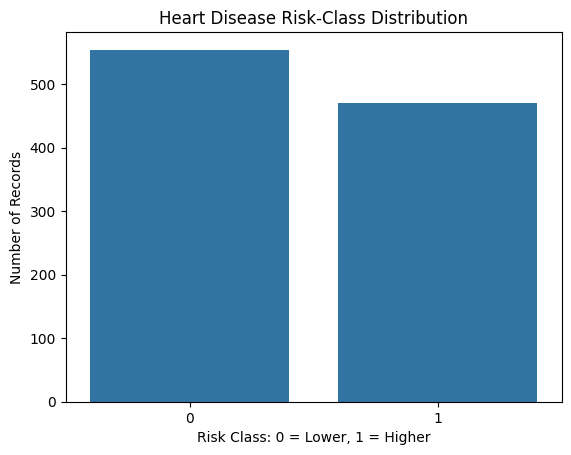

In [18]:
# Draw the target-class distribution
sns.countplot(
    data=new_df,
    x="target_binary"
)

plt.title("Heart Disease Risk-Class Distribution")
plt.xlabel("Risk Class: 0 = Lower, 1 = Higher")
plt.ylabel("Number of Records")
plt.show()

# **#Step 15: Explore age distribution**

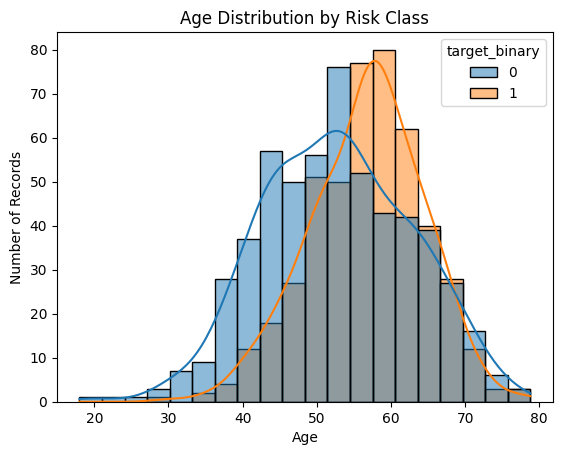

In [19]:
# Display the age distribution
sns.histplot(
    data=new_df,
    x="age",
    hue="target_binary",
    bins=20,
    kde=True
)

plt.title("Age Distribution by Risk Class")
plt.xlabel("Age")
plt.ylabel("Number of Records")
plt.show()

# **#Step 16: Explore chest-pain type**

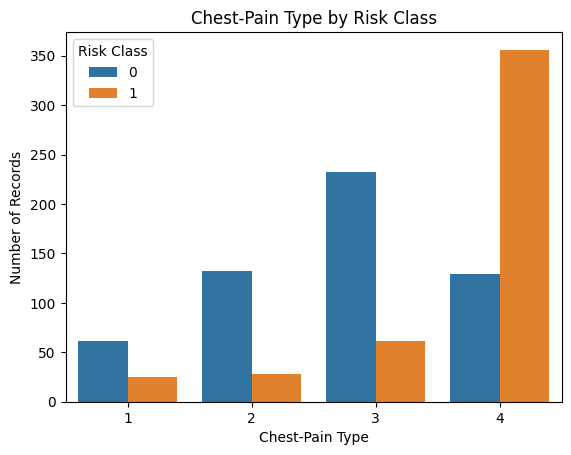

In [20]:
# Compare chest-pain type with the risk class
sns.countplot(
    data=new_df,
    x="cp",
    hue="target_binary"
)

plt.title("Chest-Pain Type by Risk Class")
plt.xlabel("Chest-Pain Type")
plt.ylabel("Number of Records")
plt.legend(title="Risk Class")
plt.show()


# **#Step 17: Explore maximum heart rate**

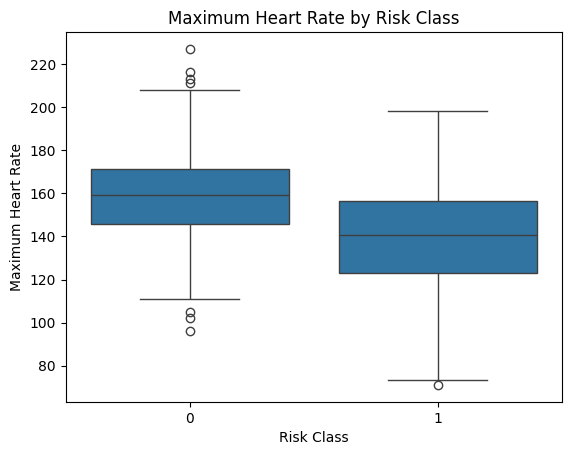

In [21]:
# Compare maximum heart rate between classes
sns.boxplot(
    data=new_df,
    x="target_binary",
    y="thalach"
)

plt.title("Maximum Heart Rate by Risk Class")
plt.xlabel("Risk Class")
plt.ylabel("Maximum Heart Rate")
plt.show()


# **#Step 18: Select the features**

#These five variables are continuous numerical features:

In [23]:
# Continuous numerical features
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]




In [24]:
#These variables are numbers in the CSV, but they represent categories:

# Categorical features represented using numbers
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]



In [25]:
#Combine the selected features:

# Combine all input features
features = numeric_features + categorical_features

print("Selected features:", features)

#We intentionally exclude:

#target_binary: the answer being predicted
#num: the original heart-disease class used to create the binary target

Selected features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


# **Step 19: Create X and y**

In [26]:
# X contains the input features
X = new_df[features].copy()

# y contains the class to predict
y = new_df["target_binary"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

#Expected shapes:

#X shape: (1024, 13)
#y shape: (1024,)


X shape: (1024, 13)
y shape: (1024,)


# **Step 20: Split the dataset**

Use 80% for training and 20% for testing.

In [27]:


# Split the data while preserving class balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

#Expected approximately:

#Training rows: 819
#Testing rows: 205

Training rows: 819
Testing rows: 205


# **Step 21: Create preprocessing**

Numerical features are standardized. Categorical features are converted using one-hot encoding.


In [28]:

# Prepare numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# **Step 22: Create the Logistic Regression model**

In [29]:
# Pipeline 1: preprocessing and Logistic Regression
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

# **Step 23: Create the Decision Tree model**

In [30]:
# Pipeline 2: preprocessing and Decision Tree
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

# **Step 24: Train both models**

In [31]:
# Train Logistic Regression
logistic_model.fit(X_train, y_train)

# Train Decision Tree
tree_model.fit(X_train, y_train)

print("Both models trained successfully.")

Both models trained successfully.


# **Step 25: Make predictions**

In [32]:
# Predict the test data
logistic_pred = logistic_model.predict(X_test)
tree_pred = tree_model.predict(X_test)

print("Predictions completed.")


Predictions completed.


# **Step 26: Evaluate Logistic Regression**

In [33]:
# Logistic Regression evaluation
print("LOGISTIC REGRESSION")
print("Accuracy :", round(accuracy_score(y_test, logistic_pred), 4))
print("Precision:", round(precision_score(y_test, logistic_pred), 4))
print("Recall   :", round(recall_score(y_test, logistic_pred), 4))
print("F1-score :", round(f1_score(y_test, logistic_pred), 4))


LOGISTIC REGRESSION
Accuracy : 0.8634
Precision: 0.8837
Recall   : 0.8085
F1-score : 0.8444


# **Step 27: Evaluate Decision Tree**

In [34]:
# Decision Tree evaluation
print("DECISION TREE")
print("Accuracy :", round(accuracy_score(y_test, tree_pred), 4))
print("Precision:", round(precision_score(y_test, tree_pred), 4))
print("Recall   :", round(recall_score(y_test, tree_pred), 4))
print("F1-score :", round(f1_score(y_test, tree_pred), 4))


DECISION TREE
Accuracy : 0.7707
Precision: 0.7975
Recall   : 0.6702
F1-score : 0.7283



Metric meanings:

Accuracy: percentage of all correct predictions.
Precision: how often predicted higher-risk records were correct.
Recall: how many actual higher-risk records the model identified.
F1-score: balance between precision and recall.

# **Step 28: Create a model-comparison table**

In [35]:
# Store both models' results
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, tree_pred)
    ],
    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, tree_pred)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, tree_pred)
    ],
    "F1-score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, tree_pred)
    ]
})

# Display rounded results
results.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8634,0.8837,0.8085,0.8444
1,Decision Tree,0.7707,0.7975,0.6702,0.7283


# **Step 29: Select the best model**

We will use F1-score because it balances precision and recall.


In [36]:

# Find the model with the highest F1-score
best_model_name = results.loc[
    results["F1-score"].idxmax(),
    "Model"
]

# Select its trained pipeline
if best_model_name == "Logistic Regression":
    best_model = logistic_model
    best_predictions = logistic_pred
else:
    best_model = tree_model
    best_predictions = tree_pred

print("Best model:", best_model_name)

Best model: Logistic Regression


# **Step 30: Display the best model’s classification report**

In [37]:
# Detailed report for the selected model
print("Best model:", best_model_name)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Lower Risk Class",
            "Higher Risk Class"
        ],
        zero_division=0
    )
)

Best model: Logistic Regression
                   precision    recall  f1-score   support

 Lower Risk Class       0.85      0.91      0.88       111
Higher Risk Class       0.88      0.81      0.84        94

         accuracy                           0.86       205
        macro avg       0.87      0.86      0.86       205
     weighted avg       0.86      0.86      0.86       205



# **Step 31: Create the confusion matrix**

In [38]:
# Calculate the confusion matrix
cm = confusion_matrix(
    y_test,
    best_predictions
)

# Display it as a table
confusion_df = pd.DataFrame(
    cm,
    index=[
        "Actual Lower Risk",
        "Actual Higher Risk"
    ],
    columns=[
        "Predicted Lower Risk",
        "Predicted Higher Risk"
    ]
)

confusion_df

,Predicted Lower Risk,Predicted Higher Risk
Actual Lower Risk,101,10
Actual Higher Risk,18,76


# **Step 32: Draw the confusion matrix**

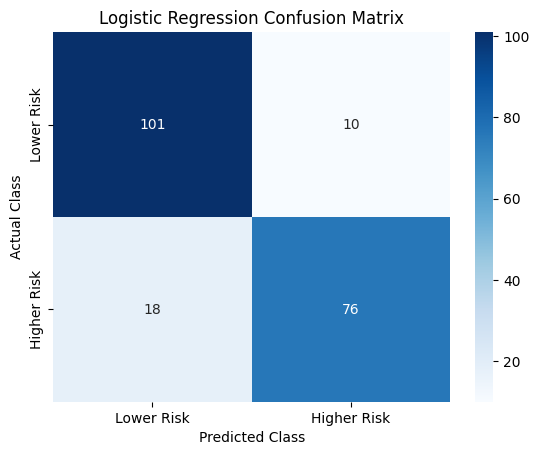

In [39]:
# Draw the best model's confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Lower Risk",
        "Higher Risk"
    ],
    yticklabels=[
        "Lower Risk",
        "Higher Risk"
    ]
)

plt.title(f"{best_model_name} Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

# **Step 33: Save the best model**

In [40]:
# Import joblib
import joblib

# Model location inside Google Drive
model_path = (
    "/content/drive/MyDrive/heart_disease/"
    "heart_disease_logistic_model.joblib"
)

# Save the complete trained pipeline
joblib.dump(
    best_model,
    model_path
)

print("Model saved successfully!")
print("Saved model:", best_model_name)
print("Saved object type:", type(best_model))
print("Location:", model_path)

Model saved successfully!
Saved model: Logistic Regression
Saved object type: <class 'sklearn.pipeline.Pipeline'>
Location: /content/drive/MyDrive/heart_disease/heart_disease_logistic_model.joblib


# **Step 34: Confirm that the file exists**

In [41]:
# Check whether the model was saved
import os

print("Model exists:", os.path.exists(model_path))

Model exists: True


# **Step 35: Reload the saved model**

In [42]:

# Load the saved model
loaded_model = joblib.load(model_path)

print("Model loaded successfully!")
print("Loaded object type:", type(loaded_model))


Model loaded successfully!
Loaded object type: <class 'sklearn.pipeline.Pipeline'>


# **Step 36: Test the reloaded model**

In [43]:
# Make predictions with the loaded model
loaded_predictions = loaded_model.predict(X_test)

# Calculate its accuracy
loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

print(
    "Loaded model accuracy:",
    round(loaded_accuracy, 4)
)

Loaded model accuracy: 0.8634


In [44]:
# Confirm that saving did not change the model
print(
    "Predictions are identical:",
    (loaded_predictions == best_predictions).all()
)


Predictions are identical: True


# **Step 37: Save the cleaned dataset**

In [45]:
# Cleaned dataset location
cleaned_data_path = (
    "/content/drive/MyDrive/heart_disease/"
    "heart_disease_cleaned.csv"
)

# Save without the index column
new_df.to_csv(
    cleaned_data_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print("Location:", cleaned_data_path)


Cleaned dataset saved successfully!
Location: /content/drive/MyDrive/heart_disease/heart_disease_cleaned.csv


# **Step 38: Confirm both files**

In [46]:
# Confirm that both files exist
print("Model exists:", os.path.exists(model_path))
print("Cleaned data exists:", os.path.exists(cleaned_data_path))

Model exists: True
Cleaned data exists: True
